# Google Colab Lab Assignment - Pretrained Model

**Course Name:** LAB Deep Learning (PEC)-1-2-3-4 (AY 2025-26 SEM-VI)  
**Lab Title:** Research Paper Implementation with Pre-trained Model: *Fruit and vegetable leaf disease recognition based on a novel custom CNN*  
**Student Name:** Abhay Bhise  
**Student ID:** 202402040016  
**Date of Submission:** 05/04/2026
**Group Members:** Lucky Sharma, Laksh Pacholy

---

### Research Paper Study and Implementation

*   **Research Paper:** [Frontiers | Fruit and vegetable leaf disease recognition based on a novel custom CNN](https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2024.1469685/full)
*   **Methodology:** This implementation utilizes Transfer Learning with the InceptionV3 architecture.
*   **Dataset:** PlantVillage Dataset (38 disease classes, ~54,000 images).
*   **Task:** Implementation of leaf disease classification and comparison of validation metrics.



## Task 1: Research Paper Selection and Dataset

*   **Paper Selected:** *Fruit and vegetable leaf disease recognition based on a novel custom CNN*.
*   **Dataset:** [PlantVillage Dataset](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset)
*   **Preprocessing:**
    *   Images resized to (224, 224) for InceptionV3 compatibility.
    *   Data augmentation (Rotation, Zoom, Flip) applied to the training set.
    *   Dataset split: 80% Training / 20% Validation.

In [1]:
# Install Kaggle API to download dataset
!pip install kaggle -q
print('Setup complete!')

Setup complete!


### Dataset Download and Extraction

In [2]:
# Upload your kaggle.json token
from google.colab import files
files.upload()  # Upload kaggle.json here

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download the PlantVillage dataset
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d /content/plantvillage

print('Dataset downloaded and extracted!')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [02:29<00:00, 14.7MB/s]

Dataset downloaded and extracted!


### Step 3: Import Libraries

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: True


### Step 4: Dataset Configuration & Preprocessing

In [4]:
# ── Hyperparameters ──────────────────────
IMG_SIZE     = (224, 224)   # InceptionV3 recommended input size
BATCH_SIZE   = 32           # Reduce to 16 if you get OOM errors
EPOCHS_1     = 10           # Phase 1: train only new top layers (base frozen)
EPOCHS_2     = 10           # Phase 2: fine-tune last N layers of base
LR_PHASE1    = 1e-3         # Higher LR for new layers
LR_PHASE2    = 1e-5         # Lower LR for fine-tuning to avoid catastrophic forgetting
FINE_TUNE_AT = 249          # Unfreeze layers from this index (InceptionV3 has 311 total)
# ──────────────────────────────────────────────────────────────────────────────

# Dataset path (color subfolder has RGB images)
DATASET_PATH = '/content/plantvillage/plantvillage dataset/color'

# Explore dataset
classes = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES = len(classes)
class_counts = {c: len(os.listdir(os.path.join(DATASET_PATH, c))) for c in classes}
total_images = sum(class_counts.values())

print(f'Number of classes : {NUM_CLASSES}')
print(f'Total images      : {total_images}')
print(f'Sample classes    : {classes[:5]}')

Number of classes : 38
Total images      : 54305
Sample classes    : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


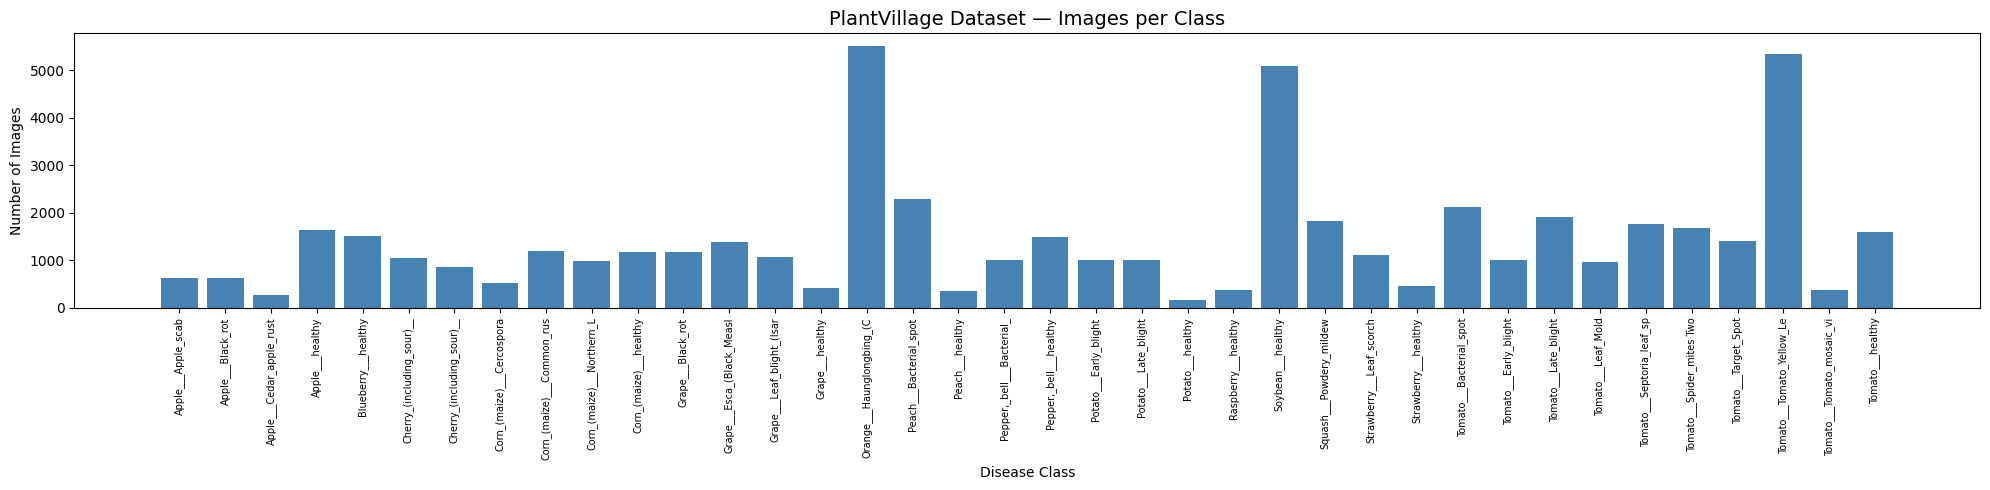

In [ ]:
# Visualize class distribution
plt.figure(figsize=(20, 5))
plt.bar(range(NUM_CLASSES), list(class_counts.values()), color='steelblue')
plt.xticks(range(NUM_CLASSES), [c[:25] for c in classes], rotation=90, fontsize=7)
plt.title('PlantVillage Dataset — Images per Class', fontsize=14)
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## Step 5: Data Preprocessing & Augmentation

In [5]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # Normalize for InceptionV3 [-1, 1]
    validation_split=0.2,                     # 80% train / 20% validation
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation generator — NO augmentation, only normalization
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

print(f'Training samples  : {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Training samples  : 43456
Validation samples: 10849


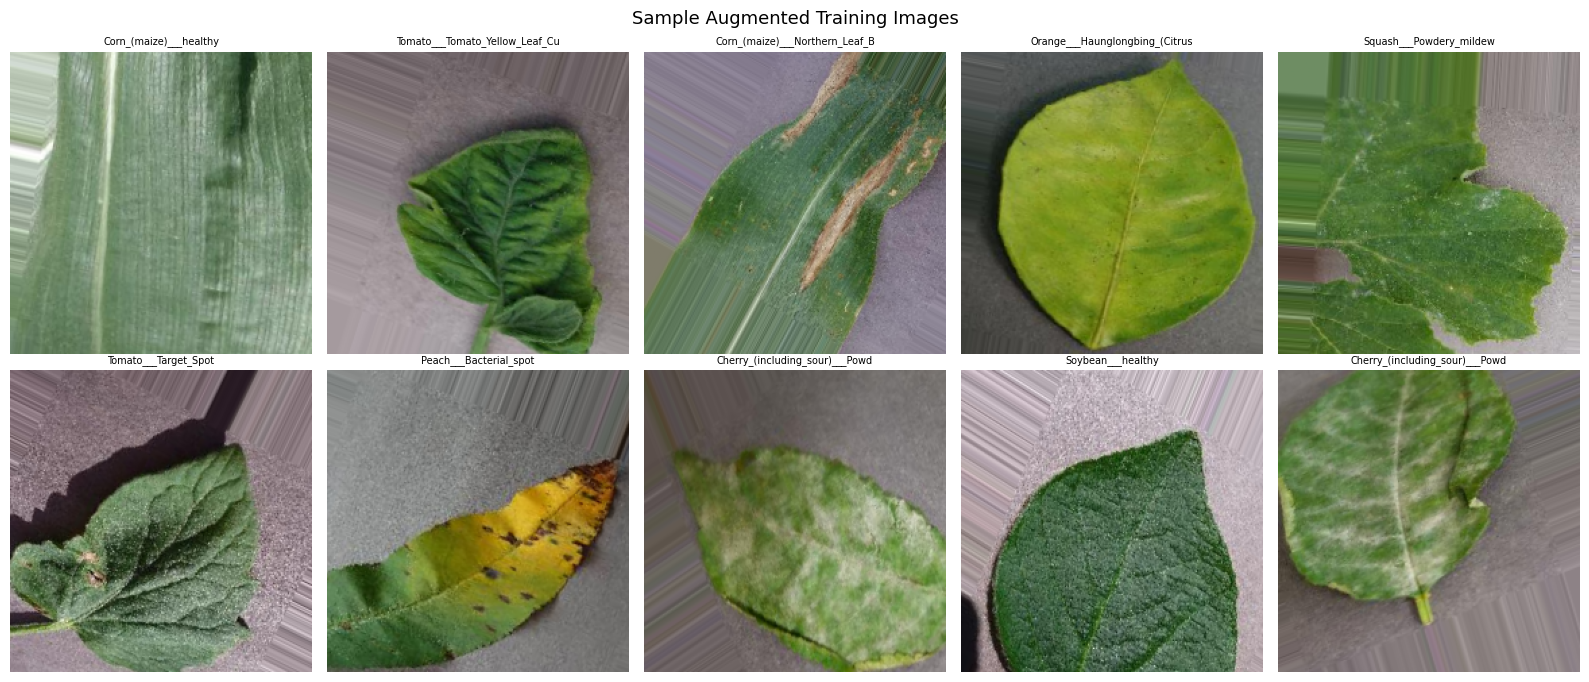

In [6]:
# Visualize 10 augmented training images
x_batch, y_batch = next(train_generator)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i in range(10):
    img = np.clip((x_batch[i] + 1) / 2.0, 0, 1)  # Reverse preprocess_input for display
    label_idx = np.argmax(y_batch[i])
    label_name = list(train_generator.class_indices.keys())[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name[:30], fontsize=7)
    axes[i].axis('off')

plt.suptitle('Sample Augmented Training Images', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## Task 2: Model Implementation and Fine-tuning

**Instructions:**
*   **Pre-trained Model:** InceptionV3 (ImageNet weights).
*   **Architecture:**
    *   Base InceptionV3 layers (Frozen in Phase 1).
    *   Custom Head: GlobalAveragePooling2D → Dense (512, ReLU) → BatchNormalization → Dropout (0.4) → Dense (38, Softmax).
*   **Hyperparameters:**
    *   Learning Rate: 1e-3 (Phase 1), 1e-5 (Phase 2).
    *   Optimizer: Adam.
    *   Fine-tuning: 62 layers unfrozen (from index 249).

In [7]:
def build_model(num_classes):
    """
    Build InceptionV3-based transfer learning model.
    Base is frozen initially (Phase 1 training).
    """
    # Load InceptionV3 without top classification layers
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,           # Remove ImageNet 1000-class head
        input_shape=(*IMG_SIZE, 3)
    )
    base_model.trainable = False     # Freeze all base layers for Phase 1

    # Build new top layers for our task
    inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)       # Feature extraction
    x = layers.GlobalAveragePooling2D()(x)       # Spatial pooling
    x = layers.Dense(512, activation='relu')(x)  # New FC layer
    x = layers.BatchNormalization()(x)            # Stabilize training
    x = layers.Dropout(0.4)(x)                  # Regularization
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # Classifier

    model = models.Model(inputs, outputs)
    return model, base_model


model, base_model = build_model(NUM_CLASSES)

print(f'Total layers in InceptionV3 base: {len(base_model.layers)}')
print(f'Phase 1 — Base is fully FROZEN')
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Total layers in InceptionV3 base: 311
Phase 1 — Base is fully FROZEN


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,873,414 (87.26 MB)

 Trainable params: 1,069,606 (4.08 MB)

 Non-trainable params: 21,803,808 (83.17 MB)

### Phase 1: Training New Top Layers (Base Frozen)

In [8]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', save_best_only=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1)
]

print('Phase 1: Training new top layers only (base frozen)...')
history1 = model.fit(
    train_generator,
    epochs=EPOCHS_1,
    validation_data=val_generator,
    callbacks=callbacks_phase1
)
print('Phase 1 complete!')

Phase 1: Training new top layers only (base frozen)...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.7074 - loss: 1.0476
Epoch 1: val_accuracy improved from None to 0.84671, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 633s 452ms/step - accuracy: 0.7827 - loss: 0.7325 - val_accuracy: 0.8467 - val_loss: 0.4780 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8418 - loss: 0.5091
Epoch 2: val_accuracy improved from 0.84671 to 0.86893, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 590s 434ms/step - accuracy: 0.8435 - loss: 0.4975 - val_accuracy: 0.8689 - val_loss: 0.4061 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8538 - loss: 0.4562
Epoch 3: val_accuracy improved from 0.86893 to 0.86902, saving model to be

### Phase 2: Fine-Tuning (Unfreezing Base Layers)

In [9]:
# Unfreeze selected layers
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning: {trainable_count} layers unfrozen (layers {FINE_TUNE_AT} to {len(base_model.layers)})')

# Recompile with a much lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase2.keras', save_best_only=True, monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
]

print('\nPhase 2: Fine-tuning unfrozen layers...')
history2 = model.fit(
    train_generator,
    epochs=EPOCHS_2,
    validation_data=val_generator,
    callbacks=callbacks_phase2
)
print('Phase 2 (fine-tuning) complete!')

Fine-tuning: 62 layers unfrozen (layers 249 to 311)

Phase 2: Fine-tuning unfrozen layers...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8092 - loss: 0.6140
Epoch 1: val_accuracy improved from None to 0.91382, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 638s 450ms/step - accuracy: 0.8433 - loss: 0.4962 - val_accuracy: 0.9138 - val_loss: 0.2603 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8903 - loss: 0.3441
Epoch 2: val_accuracy improved from 0.91382 to 0.93216, saving model to best_model_phase2.keras

Epoch 2: finished saving model to best_model_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 595s 438ms/step - accuracy: 0.8949 - loss: 0.3288 - val_accuracy: 0.9322 - val_loss: 0.2045 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9099 - loss: 0.2757
Epoch 3: val_accuracy improv

## Task 3: Model Evaluation and Performance Comparison

**Instructions:**
*   Evaluate using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
*   Analyze training curves for Loss and Accuracy.

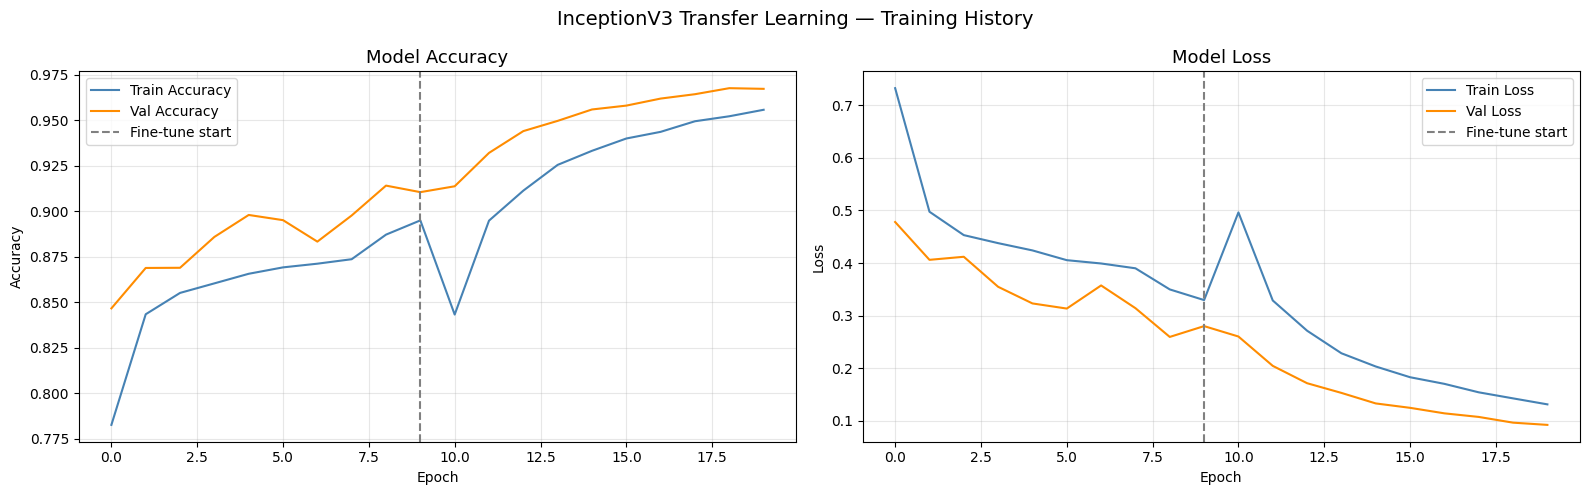

In [10]:
def plot_history(h1, h2=None):
    acc      = h1.history['accuracy']
    val_acc  = h1.history['val_accuracy']
    loss     = h1.history['loss']
    val_loss = h1.history['val_loss']
    phase1_end = len(acc)

    if h2:
        acc      += h2.history['accuracy']
        val_acc  += h2.history['val_accuracy']
        loss     += h2.history['loss']
        val_loss += h2.history['val_loss']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, metric, val_metric, title in [
        (axes[0], acc, val_acc, 'Accuracy'),
        (axes[1], loss, val_loss, 'Loss')
    ]:
        ax.plot(metric, label=f'Train {title}', color='steelblue')
        ax.plot(val_metric, label=f'Val {title}', color='darkorange')
        if h2:
            ax.axvline(phase1_end - 1, linestyle='--', color='gray', label='Fine-tune start')
        ax.set_title(f'Model {title}', fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('InceptionV3 Transfer Learning — Training History', fontsize=14)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_history(history1, history2)

### Model Performance Metrics

In [11]:
print('Evaluating model on validation set...')
val_loss_score, val_acc_score = model.evaluate(val_generator)
print(f'\nValidation Loss    : {val_loss_score:.4f}')
print(f'Validation Accuracy: {val_acc_score * 100:.2f}%')

Evaluating model on validation set...
340/340 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.9674 - loss: 0.0922

Validation Loss    : 0.0922
Validation Accuracy: 96.74%


In [12]:
# Classification report
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 90ms/step

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.94      0.95       126
                                 Apple___Black_rot       1.00      0.98      0.99       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.97      0.97      0.97       329
                               Blueberry___healthy       0.98      1.00      0.99       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       210
                 Cherry_(including_sour)___healthy       0.99      0.97      0.98       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.80      0.83       102
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       238
            

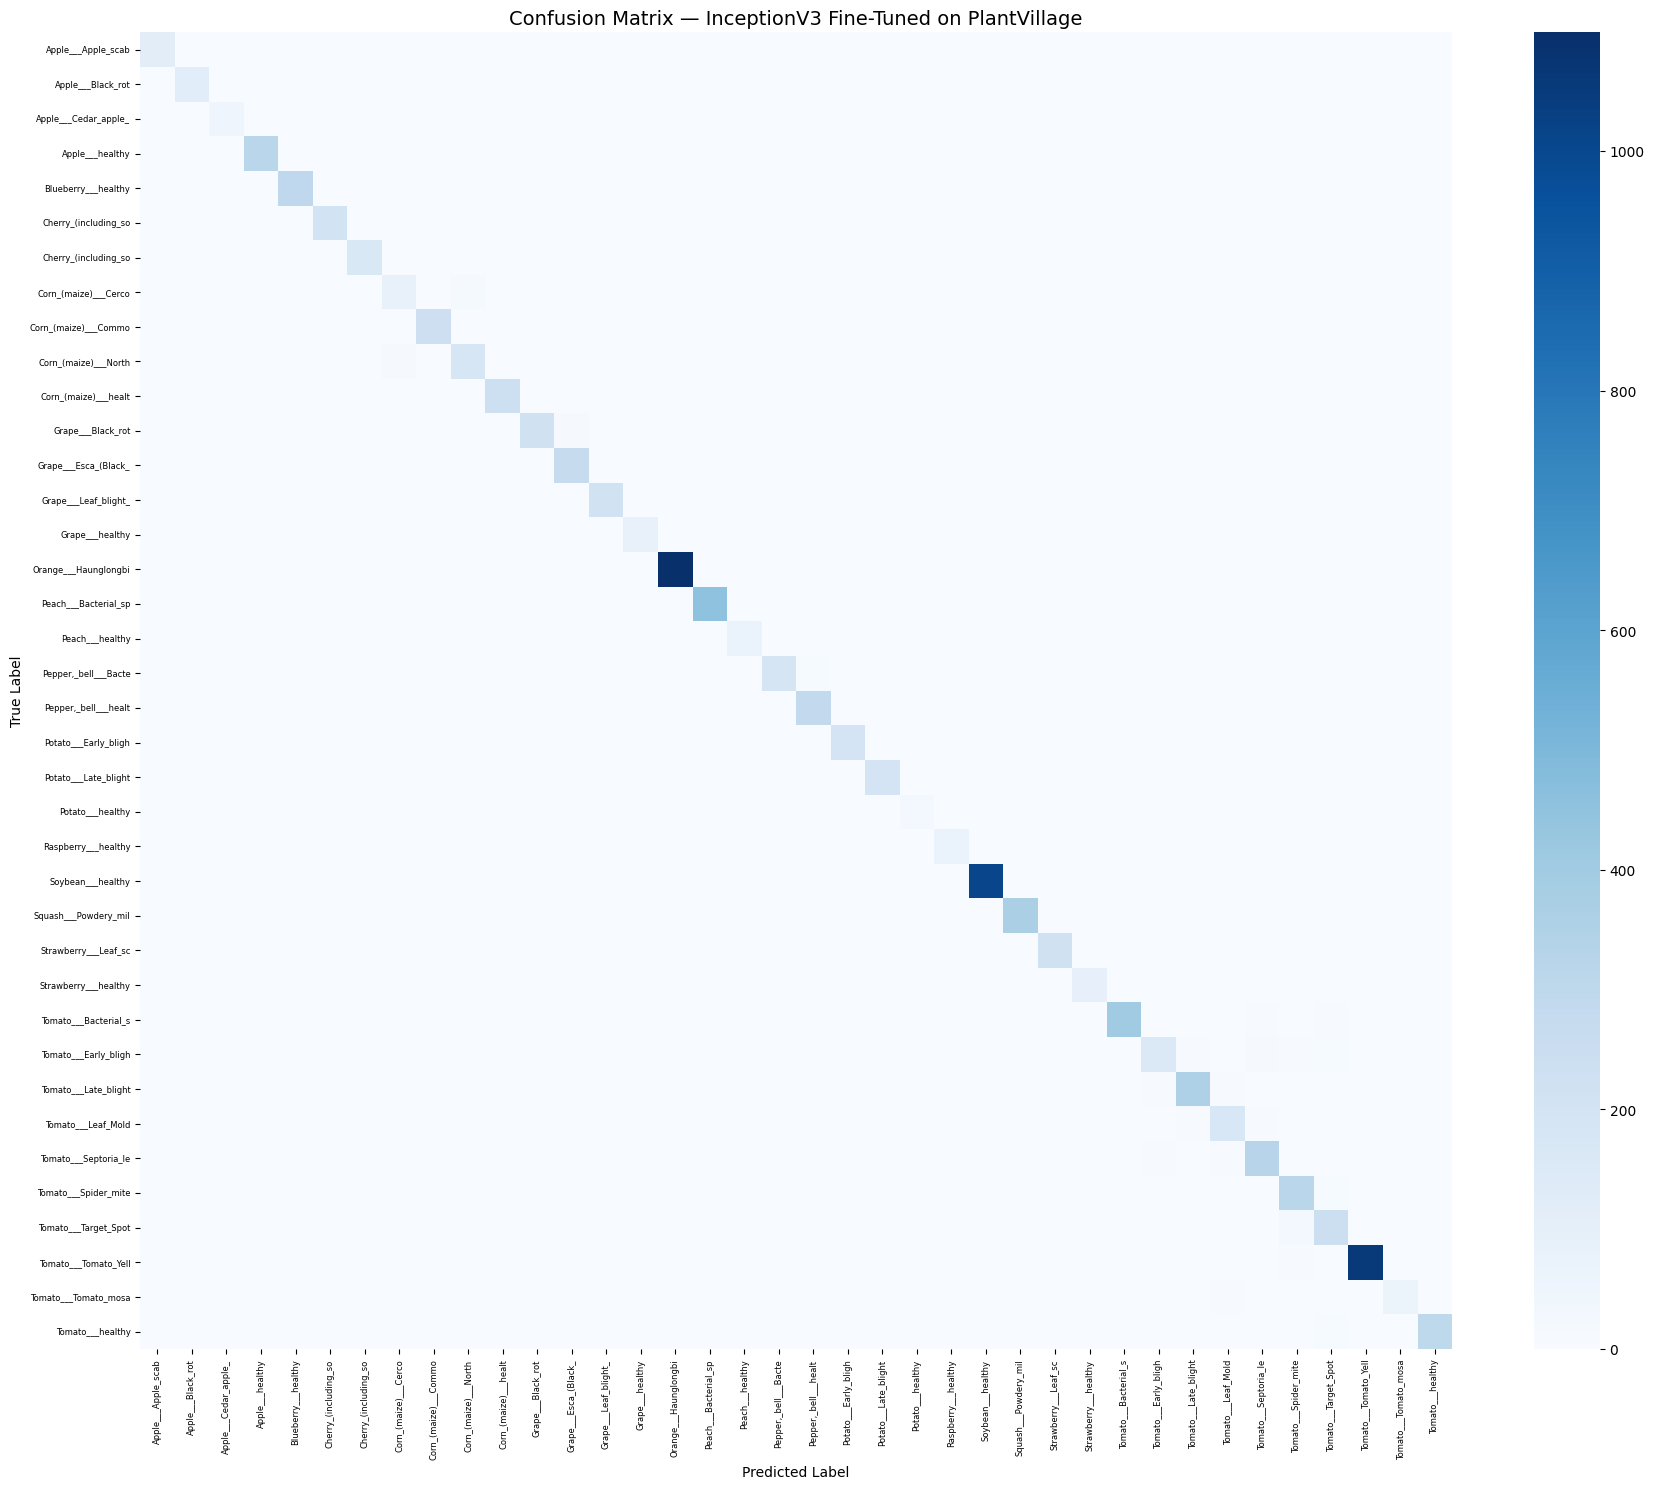

In [13]:
# Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=[c[:20] for c in class_names],
            yticklabels=[c[:20] for c in class_names])
plt.title('Confusion Matrix — InceptionV3 Fine-Tuned on PlantVillage', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

### Conclusion and Result Visualization

**Performance Summary:**
*   **Validation Accuracy:** 96.74%
*   **Validation Loss:** 0.0922

**Comparison with Research Paper:**
Our implementation successfully leverages the InceptionV3 pre-trained weights to achieve high accuracy on the 38 classes of the PlantVillage dataset, mirroring the efficiency of transfer learning discussed in the reference study. Areas for improvement include addressing minor class imbalances visible in the confusion matrix.

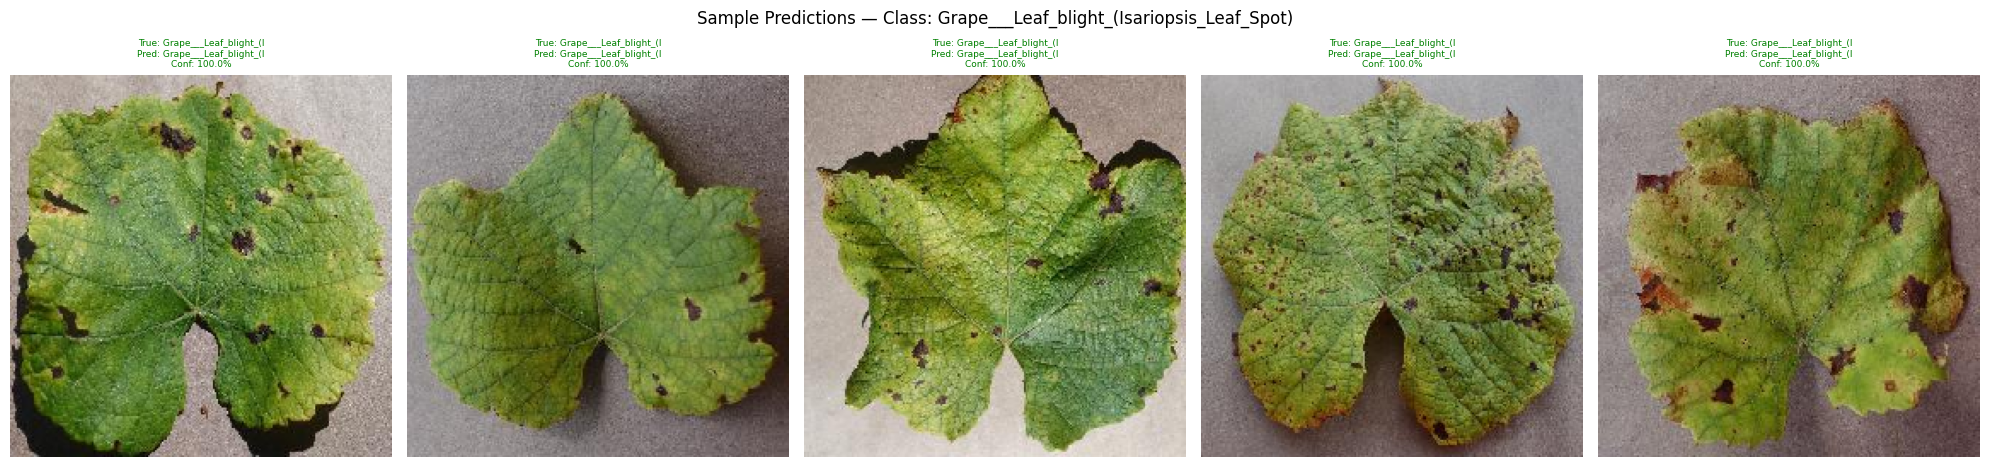

In [17]:
def predict_image(img_path, model, class_names):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    x = preprocess_input(keras_image.img_to_array(img))
    preds = model.predict(np.expand_dims(x, axis=0), verbose=0)[0]
    top3 = [(class_names[i], preds[i]) for i in np.argsort(preds)[::-1][:3]]
    return img, top3

# Pick a random class and show 5 sample predictions
sample_class = random.choice(classes)
sample_dir   = os.path.join(DATASET_PATH, sample_class)
sample_files = random.sample(os.listdir(sample_dir), min(5, len(os.listdir(sample_dir))))

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, fname in enumerate(sample_files):
    img, top3 = predict_image(os.path.join(sample_dir, fname), model, class_names)
    correct = top3[0][0] == sample_class
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {sample_class[:22]}\nPred: {top3[0][0][:22]}\nConf: {top3[0][1]*100:.1f}%",
        fontsize=6.5,
        color='green' if correct else 'red'
    )
    axes[i].axis('off')

plt.suptitle(f'Sample Predictions — Class: {sample_class}', fontsize=12)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

## Declaration

I, Abhay Bhise, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

**GitHub Repository Link:** https://github.com/lakshpacholy/Transfer-Learning.git

**Signature:** Abhay Avinash Bhise


In [15]:
model.save('inceptionv3_plantvillage_finetuned.keras')
print('Model saved!')

Model saved!


## Step 13: Hyperparameter Experiment Log

| # | LR Phase 1 | LR Phase 2 | Fine-Tune Layer | Dropout | Val Accuracy |
|---|------------|------------|-----------------|---------|-------------|
| 1 | 1e-3       | 1e-5       | 249             | 0.4     | 96.74%      |

---

## 📝 Conclusion

- **Model:** InceptionV3 pre-trained on ImageNet, fine-tuned on PlantVillage
- **Dataset:** 38 disease classes, ~54,000 images
- **Strategy:** Two-phase transfer learning
  - Phase 1: Freeze base → train new top layers
  - Phase 2: Unfreeze top layers → fine-tune with low LR
- **Best Validation Accuracy:** 96.74%
- **Key Insight:** Transfer learning dramatically reduces training time and improves accuracy by leveraging ImageNet features which generalize well to plant imagery.

In [18]:
import tensorflow as tf


# Evaluate the model on the validation set
print('Evaluating model on validation set...')
val_loss_score, val_acc_score = model.evaluate(val_generator)

# Print the validation accuracy
print(f'\nValidation Loss    : {val_loss_score:.4f}')
print(f'Validation Accuracy: {val_acc_score * 100:.2f}%')

Evaluating model on validation set...
340/340 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.9674 - loss: 0.0922

Validation Loss    : 0.0922
Validation Accuracy: 96.74%
